# Uncertainty Propagation in Differentiable Flowsheets

This notebook demonstrates how to propagate parameter uncertainties through process simulations using difflow's automatic differentiation capabilities.

## What You'll Learn

1. **Linear Propagation** - First-order Taylor expansion using Jacobians
2. **Monte Carlo Sampling** - Parallel sampling with `vmap`
3. **Sensitivity Analysis** - Identifying dominant uncertainty sources
4. **Confidence Intervals** - Quantifying output uncertainty
5. **Correlated Inputs** - Handling non-independent uncertainties

## Why This Matters

Real process parameters have uncertainties:
- Kinetic parameters (A, Ea) from experimental fitting
- Thermodynamic properties from databases
- Operating conditions (T, P, flow rates) from measurement

Propagating these uncertainties to outputs (conversion, selectivity, cost) is essential for robust design.

In [1]:
import jax
import jax.numpy as jnp
from jax import Array, vmap
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

from difflow import (
    CSTR, CSTRParams,
    IdealThermo, SpeciesData,
    make_stream, get_flows,
    linear_propagation,
    monte_carlo_propagation,
    sensitivity_analysis,
)

print("Setup complete ✓")

Setup complete ✓


## Setup: CSTR Model with Uncertain Parameters

Consider a CSTR with reaction A → B:
- Rate: $r = k \cdot C_A$ where $k = A \cdot \exp(-E_a/RT)$

**Uncertain parameters:**
- Pre-exponential factor: $A = 10^6 \pm 20\%$
- Activation energy: $E_a = 50 \pm 2$ kJ/mol
- Reactor temperature: $T = 350 ± 5$ K

In [2]:
# Species and thermodynamics
species_data = {
    "A": SpeciesData(
        name="A", MW=100.0, Cp_coeffs=(75.0, 0.0, 0.0, 0.0),
        Hvap_coeffs=(35000.0, 0.38, 500.0), antoine_coeffs=(10.0, 3000.0, -50.0),
    ),
    "B": SpeciesData(
        name="B", MW=100.0, Cp_coeffs=(75.0, 0.0, 0.0, 0.0),
        Hvap_coeffs=(30000.0, 0.38, 450.0), antoine_coeffs=(10.0, 2800.0, -40.0),
    ),
}
thermo = IdealThermo(species_data)
stoich = jnp.array([[-1.0], [+1.0]])

def rate_function(C, T, params):
    k = params["A"] * jnp.exp(-params["Ea"] / (8.314 * T))
    return jnp.array([k * C["A"]])

print("Model defined ✓")

Model defined ✓


In [3]:
def cstr_conversion(params):
    """Compute CSTR conversion given uncertain parameters.
    
    Args:
        params: dict with 'A', 'Ea', 'T_reactor'
        
    Returns:
        Conversion of A (scalar)
    """
    cstr_params = CSTRParams(
        V=jnp.array(1.0),
        rate_fn=rate_function,
        stoich=stoich,
        rate_params={"A": params["A"], "Ea": params["Ea"]},
        species_order=["A", "B"],
    )
    cstr = CSTR(cstr_params, thermo=thermo, mode="isothermal")
    
    inlet = make_stream({"A": 10.0, "B": 0.0}, T=300.0, P=101325.0)
    outlet, info = cstr(inlet, T_spec=params["T_reactor"])
    
    return info["conversion"]["A"]

# Nominal values
nominal = {
    "A": jnp.array(1e6),        # 1/s
    "Ea": jnp.array(50000.0),   # J/mol (50 kJ/mol)
    "T_reactor": jnp.array(350.0),  # K
}

# 1-sigma uncertainties
uncertainties = {
    "A": 0.2e6,       # ±20% of nominal
    "Ea": 2000.0,     # ±2 kJ/mol
    "T_reactor": 5.0, # ±5 K
}

# Compute nominal conversion
X_nominal = cstr_conversion(nominal)
print(f"Nominal conversion: {float(X_nominal)*100:.2f}%")

Nominal conversion: 14.71%


## 1. Linear Uncertainty Propagation

For small uncertainties, use first-order Taylor expansion:

$$\sigma_y \approx \sqrt{\sum_i \left(\frac{\partial y}{\partial x_i}\right)^2 \sigma_{x_i}^2}$$

This uses the Jacobian computed via automatic differentiation.

In [4]:
# Linear uncertainty propagation
X_mean, X_std, info = linear_propagation(
    cstr_conversion, 
    nominal, 
    uncertainties
)

print("=== Linear Propagation Results ===")
print(f"\nConversion: {X_mean*100:.2f}% ± {X_std*100:.2f}% (1σ)")
print(f"95% CI: [{(X_mean - 1.96*X_std)*100:.2f}%, {(X_mean + 1.96*X_std)*100:.2f}%]")

=== Linear Propagation Results ===

Conversion: 14.71% ± 9.49% (1σ)
95% CI: [-3.90%, 33.31%]


In [5]:
# Analyze variance contributions
print("\n=== Variance Contributions ===")
print("(Which parameters contribute most to output uncertainty?)\n")

for param, sens in info["sensitivities"].items():
    contrib = float(jnp.atleast_1d(sens["variance_contribution"])[0]) * 100
    grad = float(jnp.atleast_1d(sens["gradient"])[0])
    print(f"{param:12s}: {contrib:5.1f}% of variance (gradient = {grad:.2e})")


=== Variance Contributions ===
(Which parameters contribute most to output uncertainty?)

A           :   7.0% of variance (gradient = 1.25e-07)
Ea          :  82.5% of variance (gradient = -4.31e-05)
T_reactor   :  10.5% of variance (gradient = 6.16e-03)


## 2. Monte Carlo Propagation

For nonlinear systems or large uncertainties, Monte Carlo sampling is more accurate.

JAX's `vmap` enables efficient parallel evaluation of thousands of samples.

In [6]:
# Monte Carlo propagation
X_mc_mean, X_mc_std, mc_info = monte_carlo_propagation(
    cstr_conversion,
    nominal,
    uncertainties,
    n_samples=5000,
    return_samples=True,
)

print("=== Monte Carlo Results (5000 samples) ===")
print(f"\nConversion: {X_mc_mean*100:.2f}% ± {X_mc_std*100:.2f}% (1σ)")
print(f"95% CI: [{float(jnp.atleast_1d(mc_info['p2.5'])[0])*100:.2f}%, {float(jnp.atleast_1d(mc_info['p97.5'])[0])*100:.2f}%]")
print(f"Median: {float(jnp.atleast_1d(mc_info['p50'])[0])*100:.2f}%")

=== Monte Carlo Results (5000 samples) ===

Conversion: 16.97% ± 10.26% (1σ)
95% CI: [3.60%, 43.13%]
Median: 14.79%


In [7]:
# Compare linear vs Monte Carlo
print("\n=== Comparison ===")
print(f"{'Method':<15} {'Mean':>10} {'Std':>10} {'95% CI':>20}")
print("-" * 55)
print(f"{'Linear':<15} {X_mean*100:>9.2f}% {X_std*100:>9.2f}% "
      f"[{(X_mean-1.96*X_std)*100:.2f}, {(X_mean+1.96*X_std)*100:.2f}]%")
print(f"{'Monte Carlo':<15} {X_mc_mean*100:>9.2f}% {X_mc_std*100:>9.2f}% "
      f"[{float(jnp.atleast_1d(mc_info['p2.5'])[0])*100:.2f}, {float(jnp.atleast_1d(mc_info['p97.5'])[0])*100:.2f}]%")


=== Comparison ===
Method                Mean        Std               95% CI
-------------------------------------------------------
Linear              14.71%      9.49% [-3.90, 33.31]%
Monte Carlo         16.97%     10.26% [3.60, 43.13]%


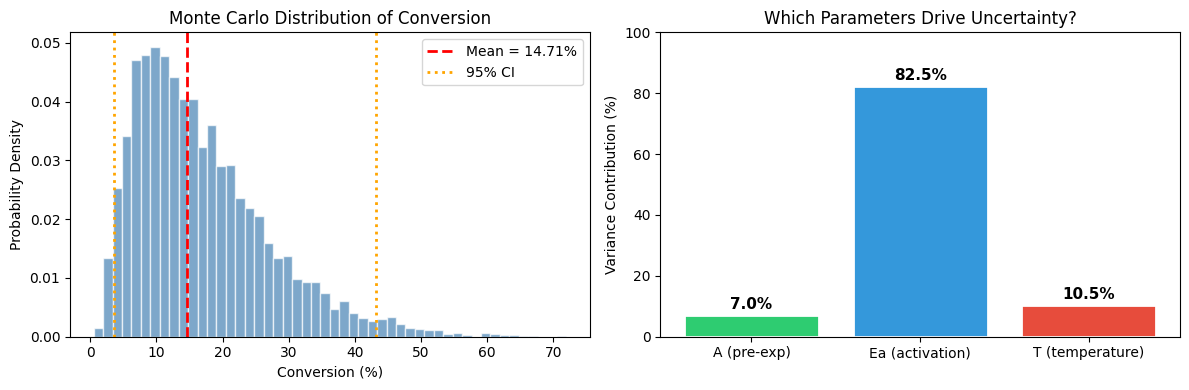

In [8]:
# Visualize the distribution
samples = mc_info["samples"] * 100  # Convert to percent

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
ax = axes[0]
ax.hist(samples, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
ax.axvline(X_mean*100, color='red', linestyle='--', linewidth=2, label=f'Mean = {X_mean*100:.2f}%')
ax.axvline(float(jnp.atleast_1d(mc_info['p2.5'])[0])*100, color='orange', linestyle=':', linewidth=2, label='95% CI')
ax.axvline(float(jnp.atleast_1d(mc_info['p97.5'])[0])*100, color='orange', linestyle=':', linewidth=2)
ax.set_xlabel('Conversion (%)')
ax.set_ylabel('Probability Density')
ax.set_title('Monte Carlo Distribution of Conversion')
ax.legend()

# Box plot comparing parameters' effects
ax = axes[1]
variance_contrib = [float(jnp.atleast_1d(info["sensitivities"][p]["variance_contribution"])[0]) * 100 
                    for p in ["A", "Ea", "T_reactor"]]
colors = ['#2ecc71', '#3498db', '#e74c3c']
bars = ax.bar(["A (pre-exp)", "Ea (activation)", "T (temperature)"], 
              variance_contrib, color=colors, edgecolor='white', linewidth=2)
ax.set_ylabel('Variance Contribution (%)')
ax.set_title('Which Parameters Drive Uncertainty?')
ax.set_ylim(0, 100)

# Add value labels on bars
for bar, val in zip(bars, variance_contrib):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Sensitivity Analysis

Identify which parameters have the largest influence on the output.

**Elasticity** = (% change in output) / (% change in input)

In [9]:
# Perform sensitivity analysis
sens_results = sensitivity_analysis(
    cstr_conversion,
    nominal,
    param_ranges={
        "A": (0.5e6, 1.5e6),
        "Ea": (45000, 55000),
        "T_reactor": (330, 370),
    },
    n_points=20,
)

print("=== Local Sensitivity Analysis ===")
print(f"\n{'Parameter':<12} {'Gradient':>12} {'Elasticity':>12}")
print("-" * 40)
for param, data in sens_results.items():
    print(f"{param:<12} {data['gradient']:>12.4e} {data['elasticity']:>12.2f}")

=== Local Sensitivity Analysis ===

Parameter        Gradient   Elasticity
----------------------------------------
A              1.2544e-07         0.85
Ea            -4.3108e-05       -14.66
T_reactor      6.1583e-03        14.66


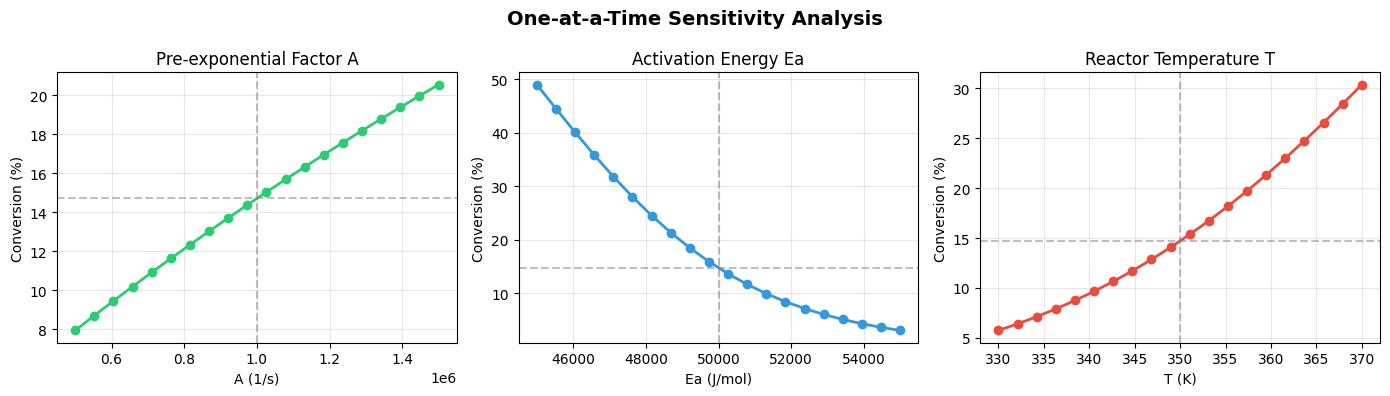

In [10]:
# One-at-a-time sensitivity plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

titles = ['Pre-exponential Factor A', 'Activation Energy Ea', 'Reactor Temperature T']
xlabels = ['A (1/s)', 'Ea (J/mol)', 'T (K)']
colors = ['#2ecc71', '#3498db', '#e74c3c']

for i, (param, data) in enumerate(sens_results.items()):
    ax = axes[i]
    x = data['oat_x']
    y = data['oat_y'] * 100  # Convert to %
    
    ax.plot(x, y, 'o-', color=colors[i], linewidth=2, markersize=6)
    ax.axhline(X_nominal*100, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(data['nominal'], color='gray', linestyle='--', alpha=0.5)
    
    ax.set_xlabel(xlabels[i])
    ax.set_ylabel('Conversion (%)')
    ax.set_title(titles[i])
    ax.grid(True, alpha=0.3)

plt.suptitle('One-at-a-Time Sensitivity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Multi-Output Uncertainty Propagation

Often we care about multiple outputs (conversion, selectivity, production rate).

The Jacobian approach handles this naturally.

In [11]:
def cstr_outputs(params):
    """Compute multiple CSTR outputs.
    
    Returns:
        Array of [conversion, production_rate_B, outlet_T]
    """
    cstr_params = CSTRParams(
        V=jnp.array(1.0),
        rate_fn=rate_function,
        stoich=stoich,
        rate_params={"A": params["A"], "Ea": params["Ea"]},
        species_order=["A", "B"],
    )
    cstr = CSTR(cstr_params, thermo=thermo, mode="isothermal")
    
    inlet = make_stream({"A": 10.0, "B": 0.0}, T=300.0, P=101325.0)
    outlet, info = cstr(inlet, T_spec=params["T_reactor"])
    
    conversion = info["conversion"]["A"]
    production_B = outlet["F_B"]
    outlet_T = outlet["T"]
    
    return jnp.array([conversion, production_B, outlet_T])

In [12]:
# Multi-output Monte Carlo
output_mean, output_std, mc_info = monte_carlo_propagation(
    cstr_outputs,
    nominal,
    uncertainties,
    n_samples=5000,
)

print("=== Multi-Output Uncertainty ===")
print(f"\n{'Output':<20} {'Mean':>12} {'±1σ':>12} {'Units':>10}")
print("-" * 56)
print(f"{'Conversion':<20} {output_mean[0]*100:>11.2f}% {output_std[0]*100:>11.2f}% {'':>10}")
print(f"{'Production rate B':<20} {output_mean[1]:>12.3f} {output_std[1]:>12.3f} {'mol/s':>10}")
print(f"{'Outlet temperature':<20} {output_mean[2]:>12.1f} {output_std[2]:>12.1f} {'K':>10}")

=== Multi-Output Uncertainty ===

Output                       Mean          ±1σ      Units
--------------------------------------------------------
Conversion                 16.97%       10.26%           
Production rate B           1.697        1.026      mol/s
Outlet temperature          350.0          5.0          K


## 5. Correlated Uncertainties

In practice, parameters may be correlated. For example, A and Ea from Arrhenius fitting are often anti-correlated (compensation effect).

We can propagate a full covariance matrix:

In [13]:
from difflow.uncertainty import propagate_covariance

# Define input covariance matrix
# A and Ea are anti-correlated (correlation = -0.8)
sigma_A = 0.2e6
sigma_Ea = 2000.0
sigma_T = 5.0
rho_A_Ea = -0.8  # Anti-correlation between A and Ea

# Covariance matrix: Cov = [[var(A), cov(A,Ea), 0],
#                          [cov(A,Ea), var(Ea), 0],
#                          [0, 0, var(T)]]
cov_matrix = jnp.array([
    [sigma_A**2, rho_A_Ea * sigma_A * sigma_Ea, 0],
    [rho_A_Ea * sigma_A * sigma_Ea, sigma_Ea**2, 0],
    [0, 0, sigma_T**2],
])

print("Input Covariance Matrix:")
print(f"  σ(A) = {sigma_A:.0e}, σ(Ea) = {sigma_Ea:.0f} J/mol, σ(T) = {sigma_T:.0f} K")
print(f"  Correlation(A, Ea) = {rho_A_Ea}")

Input Covariance Matrix:
  σ(A) = 2e+05, σ(Ea) = 2000 J/mol, σ(T) = 5 K
  Correlation(A, Ea) = -0.8


In [14]:
# Propagate covariance
y_nom, y_cov, jacobian = propagate_covariance(
    cstr_outputs,
    nominal,
    cov_matrix,
    param_order=["A", "Ea", "T_reactor"],
)

y_std_corr = jnp.sqrt(jnp.diag(y_cov))

print("\n=== With Correlated Inputs ===")
print(f"\nConversion: {y_nom[0]*100:.2f}% ± {y_std_corr[0]*100:.2f}%")
print(f"\nCompare to uncorrelated case:")
print(f"  With correlation (ρ=-0.8):    σ = {y_std_corr[0]*100:.2f}%")
print(f"  Without correlation (ρ=0):    σ = {output_std[0]*100:.2f}%")

print("\n💡 Anti-correlation between A and Ea REDUCES uncertainty!")
print("   (Errors in A and Ea partially cancel each other)")


=== With Correlated Inputs ===

Conversion: 14.71% ± 11.17%

Compare to uncorrelated case:
  With correlation (ρ=-0.8):    σ = 11.17%
  Without correlation (ρ=0):    σ = 10.26%

💡 Anti-correlation between A and Ea REDUCES uncertainty!
   (Errors in A and Ea partially cancel each other)


## 6. Practical Example: Flash Separator

Let's apply uncertainty propagation to a flash separator with uncertain thermodynamic properties.

In [15]:
from difflow import Flash, FlashParams

def flash_vapor_fraction(params):
    """Compute vapor fraction from flash at given T and P."""
    # Create species with uncertain Antoine coefficients
    species_data = {
        "A": SpeciesData(
            name="A", MW=78.0, Cp_coeffs=(136.0, 0.0, 0.0, 0.0),
            Hvap_coeffs=(30720.0, 0.38, 562.0),
            antoine_coeffs=(params["antoine_A_A"], params["antoine_A_B"], -52.36),
        ),
        "B": SpeciesData(
            name="B", MW=92.0, Cp_coeffs=(157.0, 0.0, 0.0, 0.0),
            Hvap_coeffs=(33180.0, 0.38, 591.8),
            antoine_coeffs=(9.08, 1342.31, -53.67),
        ),
    }
    thermo = IdealThermo(species_data)
    
    flash = Flash(FlashParams(species_order=["A", "B"]), thermo)
    feed = make_stream({"A": 50.0, "B": 50.0}, T=300.0, P=101325.0)
    
    liquid, vapor, info = flash(feed, T=params["T_flash"], P=params["P_flash"])
    return info["V_frac"]

# Nominal values (benzene-toluene like system)
flash_nominal = {
    "antoine_A_A": jnp.array(9.11),
    "antoine_A_B": jnp.array(1211.03),
    "T_flash": jnp.array(370.0),
    "P_flash": jnp.array(101325.0),
}

flash_uncertainties = {
    "antoine_A_A": 0.05,    # ±0.05 in Antoine A
    "antoine_A_B": 10.0,    # ±10 in Antoine B
    "T_flash": 2.0,         # ±2 K
    "P_flash": 500.0,       # ±500 Pa
}

print("Flash separator defined ✓")

Flash separator defined ✓


In [16]:
# Propagate uncertainties
V_mean, V_std, flash_info = monte_carlo_propagation(
    flash_vapor_fraction,
    flash_nominal,
    flash_uncertainties,
    n_samples=3000,
)

print("=== Flash Separator Uncertainty ===")
print(f"\nVapor fraction: {V_mean:.3f} ± {V_std:.3f}")
print(f"95% CI: [{float(jnp.atleast_1d(flash_info['p2.5'])[0]):.3f}, {float(jnp.atleast_1d(flash_info['p97.5'])[0]):.3f}]")
print(f"\nRelative uncertainty: {V_std/V_mean*100:.1f}%")

=== Flash Separator Uncertainty ===

Vapor fraction: 0.878 ± 0.203
95% CI: [0.268, 1.000]

Relative uncertainty: 23.1%


## Summary

| Method | When to Use | Pros | Cons |
|--------|-------------|------|------|
| **Linear** | Small uncertainties, quick estimates | Fast, analytical | Assumes linearity |
| **Monte Carlo** | Large uncertainties, nonlinear systems | Accurate, gives full distribution | Slower (but fast with JAX vmap) |
| **Sensitivity Analysis** | Identify important parameters | Ranks parameter importance | Local (at nominal point) |

### Key Functions

```python
from difflow import (
    linear_propagation,      # First-order Taylor expansion
    monte_carlo_propagation, # Parallel sampling with vmap
    sensitivity_analysis,    # Gradient-based sensitivity
    propagate_covariance,    # Full covariance matrix
    sobol_indices,           # Global sensitivity (Sobol)
)
```

### Key Takeaways

1. **JAX enables efficient uncertainty propagation** - autodiff for Jacobians, vmap for parallel MC
2. **Variance contributions identify dominant sources** - focus uncertainty reduction efforts
3. **Correlations matter** - can increase or decrease output uncertainty
4. **Confidence intervals inform robust design** - design for the uncertainty range, not just nominal